# DeepBranchAI: Destripe Preprocessing Demo

Demonstrates how to remove streak artifacts from light-sheet microscopy images using wavelet-based log-space FFT filtering.

**Destripe method from:**

> Allen Institute for Neural Dynamics — [aind-smartspim-destripe](https://github.com/AllenNeuralDynamics/aind-smartspim-destripe)  
> Licensed under MIT. Implements log-space FFT filtering for removing horizontal/vertical
> streak noise from SmartSPIM light-sheet microscopy datasets.

This notebook generates a synthetic striped image, applies the destripe filter with different parameter configurations, and visualizes the results.

## Step 1: Install and Import

In [1]:
import subprocess, sys, tempfile
from pathlib import Path

def load_destripe_filter():
    try:
        from aind_smartspim_destripe.filtering import log_space_fft_filtering
        print("aind-smartspim-destripe already available")
        return log_space_fft_filtering
    except ImportError:
        print("Loading aind-smartspim-destripe from GitHub source...")

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "PyWavelets", "scikit-image",
    ])

    repo_dir = Path(tempfile.gettempdir()) / "aind-smartspim-destripe"
    if not repo_dir.exists():
        subprocess.check_call([
            "git", "clone", "--depth", "1", "--quiet",
            "https://github.com/AllenNeuralDynamics/aind-smartspim-destripe.git",
            str(repo_dir),
        ])

    code_dir = repo_dir / "code"
    if str(code_dir) not in sys.path:
        sys.path.insert(0, str(code_dir))

    from aind_smartspim_destripe.filtering import log_space_fft_filtering
    print("aind-smartspim-destripe loaded")
    return log_space_fft_filtering

log_space_fft_filtering = load_destripe_filter()

import numpy as np
import matplotlib.pyplot as plt

Loading aind-smartspim-destripe from GitHub source...


aind-smartspim-destripe loaded


## Step 2: Generate Synthetic Striped Image

In [2]:
np.random.seed(42)

# Create a synthetic tissue-like image with blob structures
from scipy.ndimage import gaussian_filter

size = 512
tissue = np.random.rand(size, size).astype(np.float64)
tissue = gaussian_filter(tissue, sigma=8) * 200 + 30  # smooth blobs

# Add bright circular structures (simulating vessels/cells)
yy, xx = np.mgrid[:size, :size]
for _ in range(15):
    cx, cy = np.random.randint(50, size-50, 2)
    r = np.random.randint(10, 40)
    mask = ((xx - cx)**2 + (yy - cy)**2) < r**2
    tissue[mask] += np.random.uniform(50, 150)

tissue = np.clip(tissue, 0, 255)

# Add vertical stripe artifacts (simulating light-sheet scanning noise)
stripes = np.zeros_like(tissue)
for x in range(size):
    stripes[:, x] = np.random.normal(0, 1) * (8 + 4 * np.sin(x * 0.05))
stripes = gaussian_filter(stripes, sigma=[20, 0.5])  # smooth along Y, sharp along X

striped_image = tissue + stripes * 3
striped_image = np.clip(striped_image, 0, 255)

print(f"Image shape: {striped_image.shape}")
print(f"Value range: [{striped_image.min():.1f}, {striped_image.max():.1f}]")

Image shape: (512, 512)
Value range: [50.2, 255.0]


## Step 3: Apply Destripe Filtering

In [3]:
# The filter removes horizontal stripes, so we transpose for vertical stripes
# Two configurations: conservative (preserves detail) and aggressive (stronger filtering)

configurations = {
    'Conservative (sigma=128, threshold=12)': {'sigma': 128, 'max_threshold': 12},
    'Aggressive (sigma=64, threshold=3)':      {'sigma': 64,  'max_threshold': 3},
}

results = {}
for name, cfg in configurations.items():
    print(f"Applying: {name}")
    # Transpose to treat vertical stripes as horizontal
    img_t = striped_image.T
    filtered_t = log_space_fft_filtering(
        img_t,
        wavelet='db3',
        level=None,
        sigma=cfg['sigma'],
        max_threshold=cfg['max_threshold'],
    )
    results[name] = filtered_t.T  # transpose back
    print(f"  Done.")

print(f"\nFiltering complete.")

Applying: Conservative (sigma=128, threshold=12)
  Done.
Applying: Aggressive (sigma=64, threshold=3)
  Done.

Filtering complete.


## Step 4: Visualize Results

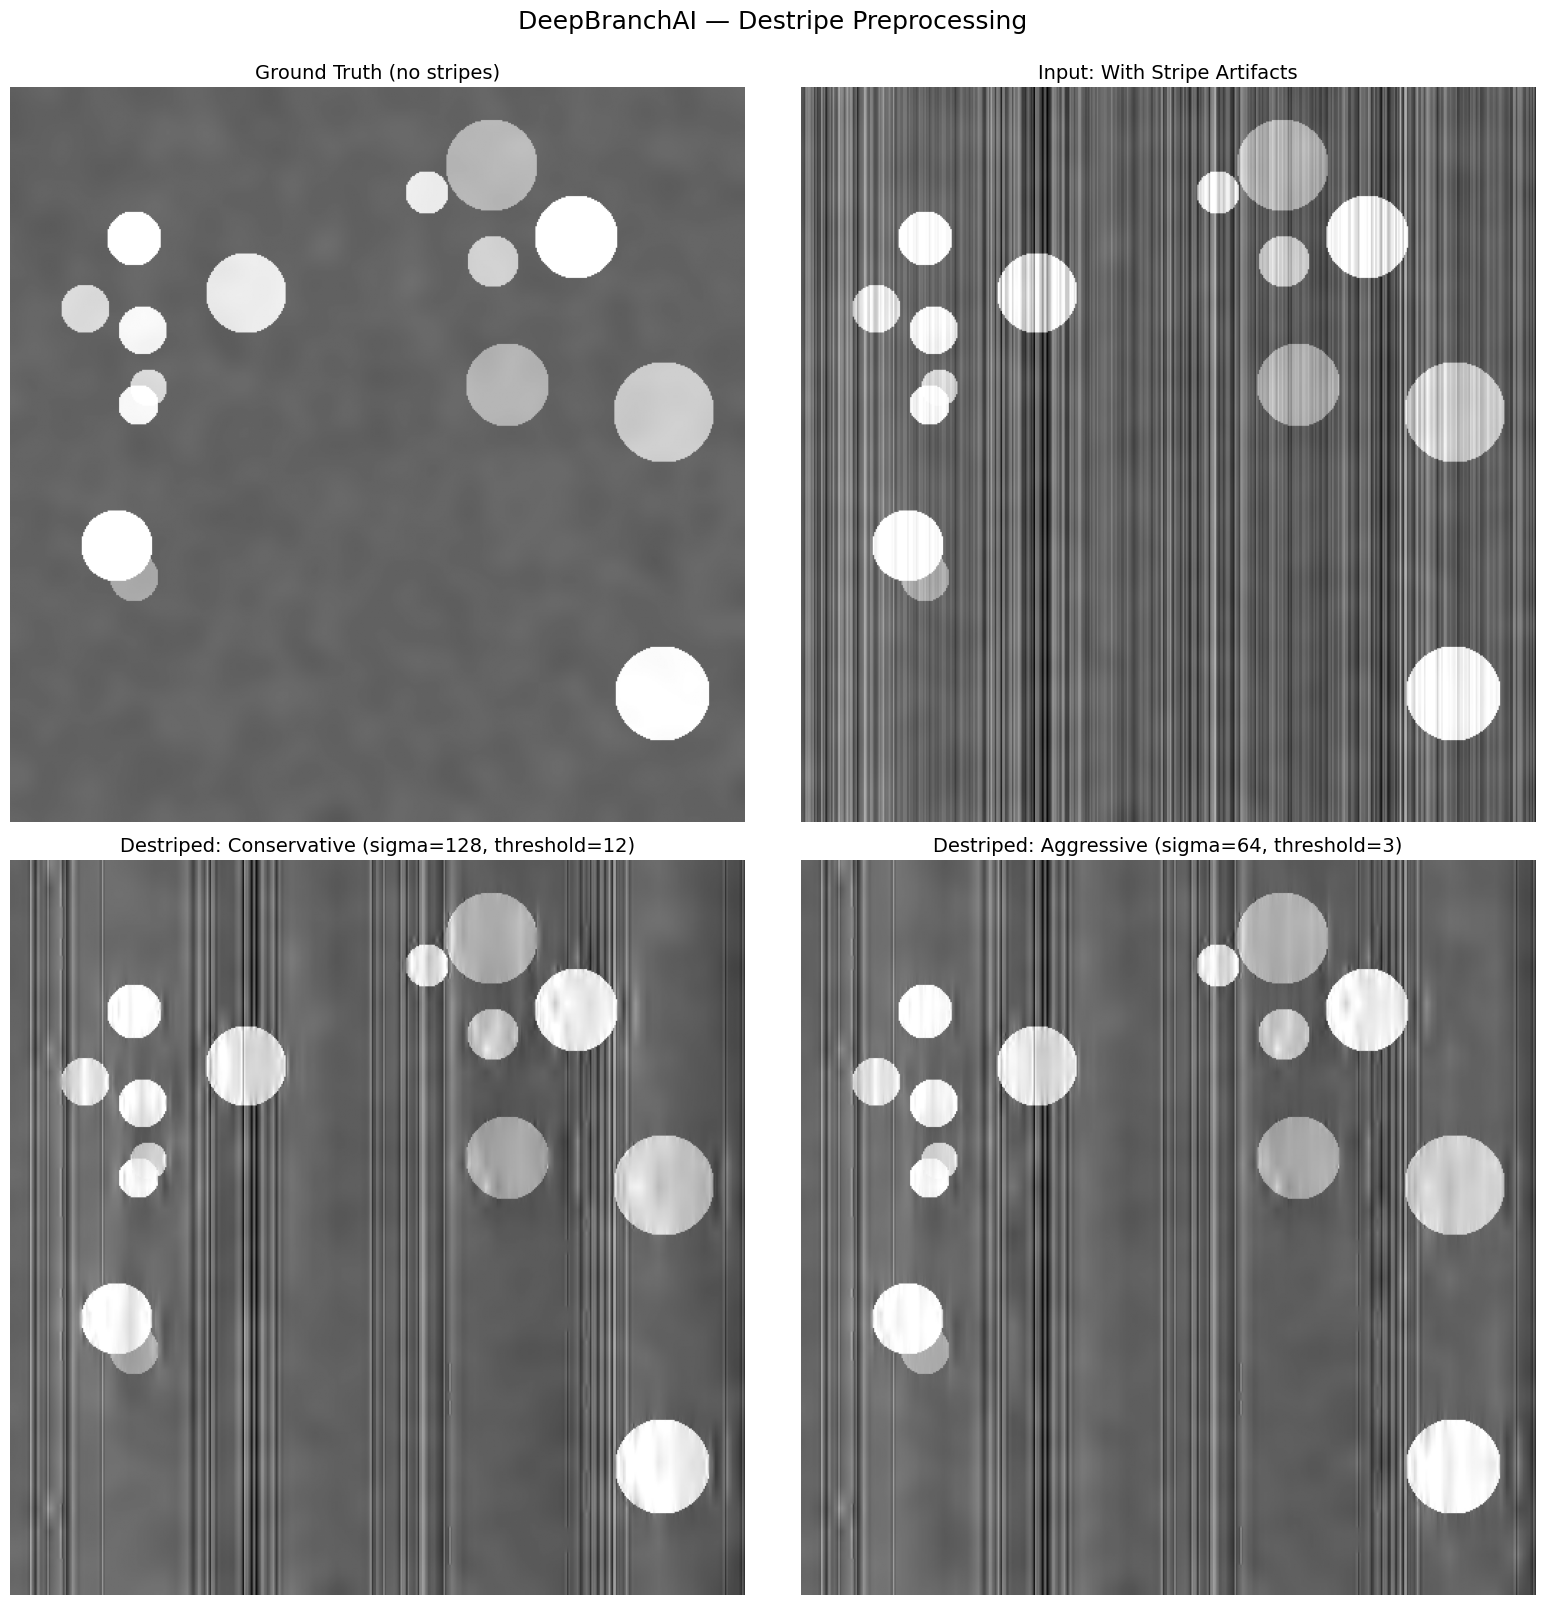

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

vmin, vmax = striped_image.min(), striped_image.max()

axes[0, 0].imshow(tissue, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Ground Truth (no stripes)', fontsize=14)
axes[0, 0].axis('off')

axes[0, 1].imshow(striped_image, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('Input: With Stripe Artifacts', fontsize=14)
axes[0, 1].axis('off')

for ax, (name, img) in zip(axes[1], results.items()):
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(f'Destriped: {name}', fontsize=14)
    ax.axis('off')

plt.suptitle('DeepBranchAI — Destripe Preprocessing', fontsize=18, y=1.0)
plt.tight_layout()
plt.show()

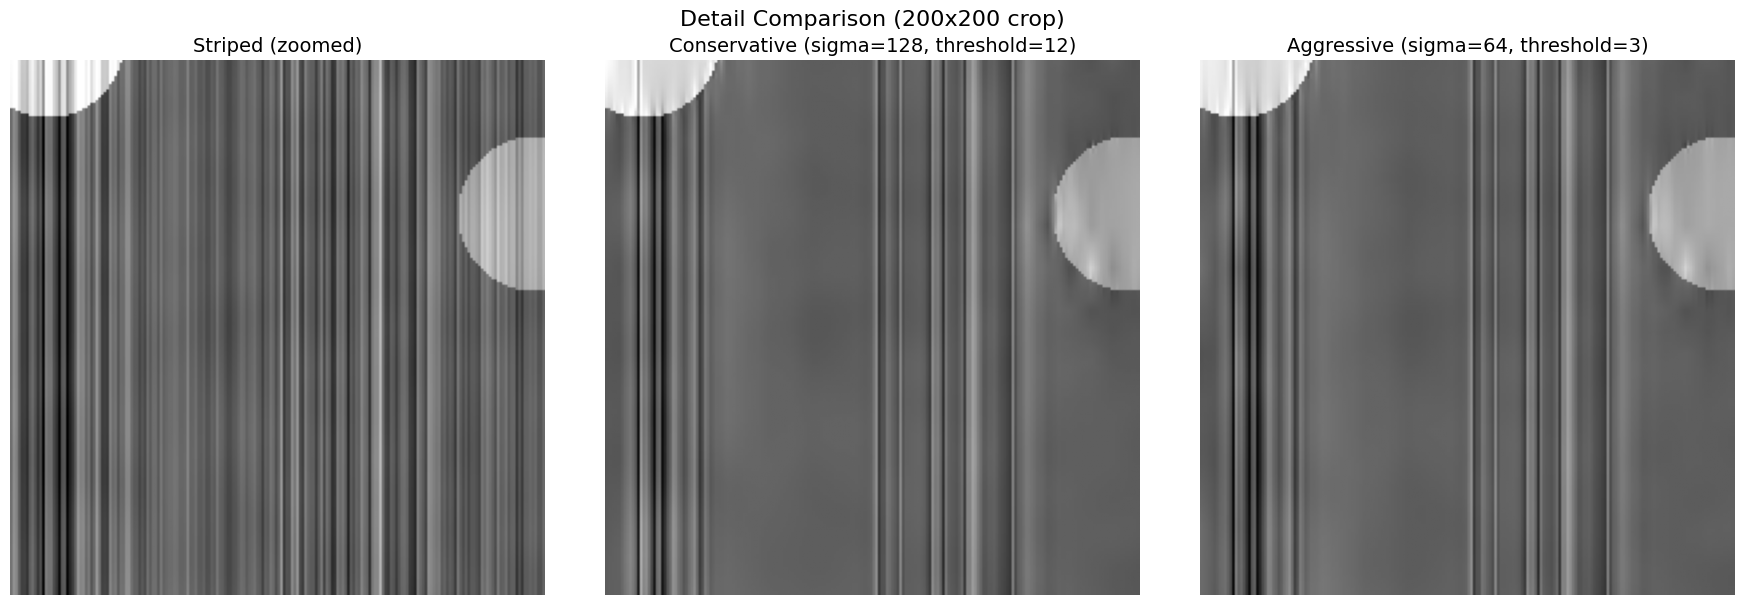

In [5]:
# Zoom in on a region to compare detail preservation
roi = (slice(150, 350), slice(150, 350))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(striped_image[roi], cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Striped (zoomed)', fontsize=14)
axes[0].axis('off')

for ax, (name, img) in zip(axes[1:], results.items()):
    ax.imshow(img[roi], cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(f'{name}', fontsize=14)
    ax.axis('off')

plt.suptitle('Detail Comparison (200x200 crop)', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

## Parameters Guide

| Parameter | Description | Effect |
|-----------|-------------|--------|
| `sigma` | Gaussian filter bandwidth | Higher = more selective, preserves more detail |
| `max_threshold` | Wavelet coefficient threshold | Lower = more aggressive stripe removal |
| `wavelet` | Wavelet type (default: db3) | Controls decomposition basis |
| `level` | Decomposition level (None = auto) | Depth of wavelet analysis |

For light-sheet data with **faint stripes**, use conservative settings (sigma=128, threshold=12).  
For data with **strong stripes**, use aggressive settings (sigma=64, threshold=3).